# Laboratorio 7 — NLP y embeddings
**Ian Cumes · carné 23236 · entrega individual**

Este notebook reúne investigación, implementación SGNS propia, evaluación vectorial y clasificación AG News. Los resultados se leen de registros reales del entrenamiento. El código completo está en `src/`, los manifiestos y métricas en `artifacts/`; los vectores grandes se distribuyen en una release.

[Repositorio](https://github.com/iancumes/Lab7DeepLearning) · [Enunciado](https://github.com/iancumes/Lab7DeepLearning/blob/main/Laboratorio_7_NLP_Embeddings.md)

**Ejecución:** todas las celdas funcionan en un kernel nuevo con dependencias instaladas. En Colab se clona el repositorio y se instalan las versiones fijadas; seleccionar el runtime 2025.10 con Python 3.12. Si Colab solicita reinicio después de instalar, reiniciar el kernel y ejecutar todas las celdas. `REENTRENAR=True` ejecuta los experimentos completos o reanuda checkpoints presentes. Si solo hay métricas publicadas y faltan checkpoints, el script preserva esos resultados en `tmp/` e inicia un entrenamiento nuevo. La ejecución predeterminada reconstruye tablas y figuras desde las métricas publicadas, evitando repetir entrenamiento y test. Se necesitan Python 3.11/3.12 y varios GB de disco para reentrenar.

In [1]:
from pathlib import Path
import os, sys, subprocess
EN_COLAB = 'google.colab' in sys.modules
if EN_COLAB:
    raiz = Path('/content/Lab7DeepLearning')
    if not raiz.exists():
        subprocess.run(['git','clone','https://github.com/iancumes/Lab7DeepLearning.git',str(raiz)],check=True)
    os.chdir(raiz)
    subprocess.run([sys.executable,'-m','pip','install','-q','-r','requirements.txt'],check=True)
else:
    raiz = Path.cwd()
    if raiz.name == 'notebooks': raiz = raiz.parent
    os.chdir(raiz)
sys.path.insert(0,str(raiz))
REENTRENAR = False
print('Repositorio:',raiz,'· reentrenar:',REENTRENAR)

Repositorio: C:\Users\ianro\OneDrive\Documentos\Uvg\Octavo Semestre\Deep Learning\Lab7DeepLearning · reentrenar: False


In [2]:
import json, inspect
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image
from src.common import ART, CHECKPOINTS, load_json, experiment_configs
from src.preprocessing import tokenize, normalize, pair_batches, pair_count
from src.embeddings import SGNS, AnalogyEngine, train_sgns, train_gensim
from src.classification import NewsClassifier, train_neural, train_tfidf
from src.reporting import tables, figures
pd.set_option('display.max_rows',200)
pd.set_option('display.max_columns',20)
pd.set_option('display.max_colwidth',160)
if REENTRENAR:
    subprocess.run([sys.executable,'-u','scripts/run_experiments.py'],check=True)
assert (ART/'completion.json').exists(), 'Ejecutar primero los experimentos completos.'
print('Evidencia de ejecución:',load_json(ART/'completion.json'))
subprocess.run([sys.executable,'-m','pytest','-q'],check=True)

C:\Users\ianro\OneDrive\Documentos\Uvg\Octavo Semestre\Deep Learning\Lab7DeepLearning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Evidencia de ejecución: {'complete': True, 'seconds_current_invocation': 2152.322394941, 'sgns_iterations': 7, 'sgns_epochs': 21, 'classifiers': 32, 'final_test_models': 20, 'seed': 23236}


CompletedProcess(args=['C:\\Users\\ianro\\OneDrive\\Documentos\\Uvg\\Octavo Semestre\\Deep Learning\\Lab7DeepLearning\\.venv\\Scripts\\python.exe', '-m', 'pytest', '-q'], returncode=0)

## 1 Investigación y preprocesamiento

### Word2Vec y GloVe
CBOW predice la palabra central a partir de su contexto; Skip-Gram predice palabras del contexto desde el centro. SGNS reemplaza el softmax de todo el vocabulario por discriminación binaria entre pares observados y negativos. Las dos tablas cumplen papeles distintos: vectores de entrada del centro y vectores de salida del contexto. Se conserva la tabla de entrada para evaluación y clasificación.

GloVe minimiza un error ponderado sobre logaritmos de coocurrencias globales: $J=\sum_{ij}f(X_{ij})(w_i^T\tilde w_j+b_i+\tilde b_j-\log X_{ij})^2$. La ponderación limita la influencia de pares excesivamente frecuentes; el modelo incorpora estadísticas del corpus completo. Word2Vec actualiza ejemplos locales y GloVe usa una matriz global dispersa. Ambos aprenden relaciones distribucionales y pueden reflejar sesgos del corpus. No distinguen sentidos de una misma palabra ni conservan orden cuando se promedian.

[Mikolov et al. 2013](https://papers.nips.cc/paper_files/paper/2013/hash/9aa42b31882ec039965f3c4923ce901b-Abstract.html) · [Pennington et al. 2014](https://nlp.stanford.edu/pubs/glove.pdf)

### Capas de PyTorch
`nn.Embedding(V,d)` transforma IDs enteros en filas de una matriz entrenable. `padding_idx` evita actualizar esa fila; `sparse=True` genera gradientes dispersos compatibles con SGD. `from_pretrained(weights, freeze=True)` inicializa desde una matriz y congela sus pesos; `freeze=False` permite ajuste. `EmbeddingBag` reduce los embeddings de cada documento por `mean`, `sum` o `max` sin materializar padding. Para una lista de IDs concatenados, `offsets` señala el comienzo de cada documento; `include_last_offset=True` añade además el límite final. Aquí se usa `mean`, offsets iniciales y `padding_idx=0`.

[Embedding, PyTorch 2.8](https://docs.pytorch.org/docs/2.8/generated/torch.nn.Embedding.html) · [EmbeddingBag, PyTorch 2.8](https://docs.pytorch.org/docs/2.8/generated/torch.nn.EmbeddingBag.html)

### Normalización
Se usan minúsculas, comillas ASCII, reparación de `@-@`, `@,@`, `@.@`, eliminación de `<unk>`, `<pad>` y signos de encabezado. Se conservan números y puntuación, sin stemming ni stopwords. La expresión regular admite palabras Unicode y apóstrofos internos. Es compatible con GloVe uncased, aunque algunas contracciones y números tienen segmentación distinta. Un artículo empieza en un encabezado de nivel uno; una línea no equivale a un artículo.

In [3]:
print(inspect.getsource(normalize))
print(inspect.getsource(tokenize))
ejemplos=pd.DataFrame(load_json(ART/'tokenizer_examples.json'))
ejemplos['iguales']=ejemplos.custom.map(tuple)==ejemplos.nltk.map(tuple)
display(ejemplos)

def normalize(text):
    """Minúsculas, comillas ASCII y reparación de marcadores de WikiText.

    Se conservan números y puntuación como tokens: GloVe es uncased pero
    contiene ambos. No se eliminan stopwords ni se hace stemming/lemmatization.
    Los encabezados no aportan signos '=' y los especiales no son palabras.
    """
    text = text.lower().replace("’", "'").replace("‘", "'")
    text = text.replace("“", '"').replace("”", '"')
    for marker, replacement in [("@-@", "-"), ("@,@", ","), ("@.@", ".")]:
        text = text.replace(marker, replacement)
    text = SPECIAL.sub(" ", text)
    if re.match(r"^\s*=+\s.*\s=+\s*$", text):
        text = text.strip().strip("=").strip()
    return text

def tokenize(text):
    return WORD.findall(normalize(text))



,sentence,custom,nltk,iguales
0,I can't believe it's already October.,"[i, can't, believe, it's, already, october, .]","[i, ca, n't, believe, it, 's, already, october, .]",False
1,She won't buy John's laptop.,"[she, won't, buy, john's, laptop, .]","[she, wo, n't, buy, john, 's, laptop, .]",False
2,"A state-of-the-art computer costs $1,299.50.","[a, state, -, of, -, the, -, art, computer, costs, $, 1,299.50, .]","[a, state-of-the-art, computer, costs, $, 1,299.50, .]",False
3,Dr. Smith lives in the U.S.A.,"[dr, ., smith, lives, in, the, u, ., s, ., a, .]","[dr., smith, lives, in, the, u.s.a, .]",False
4,We're testing NLP-based models.,"[we're, testing, nlp, -, based, models, .]","[we, 're, testing, nlp-based, models, .]",False
5,"They've run 10,000 experiments.","[they've, run, 10,000, experiments, .]","[they, 've, run, 10,000, experiments, .]",False
6,The king's daughter isn't a queen.,"[the, king's, daughter, isn't, a, queen, .]","[the, king, 's, daughter, is, n't, a, queen, .]",False
7,"He said, ""Hello... world!""","[he, said, ,, "", hello, ., ., ., world, !, ""]","[he, said, ,, ``, hello, ..., world, !, '']",False
8,"Wikipedia uses @-@ markers and @,@ commas.","[wikipedia, uses, -, markers, and, ,, commas, .]","[wikipedia, uses, -, markers, and, ,, commas, .]",True
9,Email user@example.com or visit https://uvg.edu.gt.,"[email, user, @, example, ., com, or, visit, https, :, /, /, uvg, ., edu, ., gt, .]","[email, user, @, example.com, or, visit, https, :, //uvg.edu.gt, .]",False


La comparación usa `TreebankWordTokenizer` sobre la misma normalización para aislar diferencias de tokenización. NLTK separa contracciones como `can't` y `John's`; el tokenizador propio conserva apóstrofos internos. Ambos pueden fragmentar abreviaturas, URL y correos. No se fuerza igualdad: esas diferencias explican parte del OOV respecto de GloVe.

In [4]:
corpus=load_json(ART/'corpus.json')
display(pd.DataFrame(corpus['splits']).T)
display(pd.DataFrame(corpus['thresholds']))
display(pd.DataFrame([{'top_k':int(k),'cobertura':v} for k,v in corpus['zipf_coverage'].items()]))
print('Artículos seleccionados:',corpus['selected_articles'])
print('Tokens normalizados seleccionados:',corpus['selected_tokens'])
print('SHA256 del corpus:',corpus['selected_sha256'])
assert corpus['selected_tokens']>=20_000_000
print('Primeros artículos del manifiesto:'); display(pd.DataFrame(corpus['articles']).head(10))

,lines,nonempty_lines,whitespace_tokens,normalized_tokens,articles
test,4358,2891,241211,242994,62
train,1801350,1165029,101425671,102356963,29443
validation,3760,2461,213886,216023,60


,min_count,vocabulary_size,unknown_token_fraction
0,1,211559,0.000000
1,5,72216,0.011397
2,10,49323,0.018911


,top_k,cobertura
0,10,0.286949
1,1000,0.697992
2,30000,0.962568


Artículos seleccionados: 5886
Tokens normalizados seleccionados: 20000727
SHA256 del corpus: b2fb33a9328031953bdd1e5b0569563f1ad09f4310155a875b11b72239b8a816
Primeros artículos del manifiesto:


,article_id,start,end,tokens
0,1456,85194,85230,2612
1,4120,241933,241999,3243
2,26155,1592499,1592565,3175
3,6243,369982,370035,2308
4,6848,406836,406916,3077
5,26587,1619104,1619130,893
6,14179,858068,858088,1190
7,29352,1795936,1796019,6054
8,20350,1238423,1238435,667
9,22504,1367106,1367175,5544


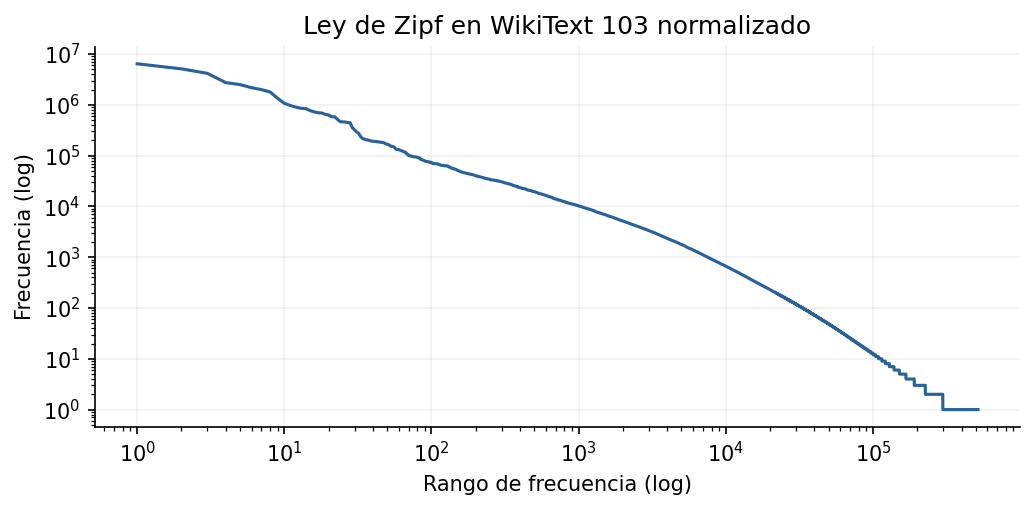

In [5]:
from src.reporting import tables as construir_tablas
tablas=construir_tablas()
figures(tablas)
display(Image(filename=str(ART/'figures'/'zipf.png')))

Zipf relaciona rango y frecuencia aproximadamente por una potencia inversa; la gráfica usa ejes logarítmicos. La concentración del corpus justifica subsampling: stopwords aportan muchos pares redundantes. `min_count` controla rareza, memoria y OOV; `min_count=1` conserva todos los tipos y 5/10 eliminan los menos observados. Los tokens excluidos por min_count no se entrenan como una palabra artificial `<unk>`.

Se permutan artículos completos con semilla 23236 hasta superar 20 millones de tokens normalizados. Los subconjuntos del 25 %, 50 % y 100 % son prefijos anidados de esa selección y cierran en límites de artículos. Por eso pueden exceder ligeramente su porcentaje nominal. Las líneas normalizadas se dividen en bloques de máximo 1000 tokens para evitar truncamiento de gensim; ambos entrenamientos usan exactamente el mismo archivo y límites de contexto.

In [6]:
configuraciones=load_json(ART/'configurations.json')
display(pd.DataFrame(configuraciones))
metadata=[load_json(ART/'ids'/c['name']/'meta.json') for c in configuraciones] if (ART/'ids'/'base100'/'meta.json').exists() else load_json(ART/'corpus_configurations.json')
display(pd.DataFrame([{'configuración':c['name'],'tokens':m['corpus_tokens'],'tokens_elegibles':m['eligible_tokens'],'vocabulario':len(m['vocabulary']),'pares_antes':m['pairs_before_subsampling'],'sha256':m['corpus_sha256']} for c,m in zip(configuraciones,metadata)]))

,dim,window,negatives,fraction,min_count,sample,epochs,initial_lr,final_lr,batch_size,seed,ns_exponent,dynamic_window,name
0,100,5,5,1.00,5,0.0001,3,0.025,0.0001,4096,23236,0.75,False,base100
1,50,5,5,1.00,5,0.0001,3,0.025,0.0001,4096,23236,0.75,False,dim50
2,300,5,5,1.00,5,0.0001,3,0.025,0.0001,4096,23236,0.75,False,dim300
3,100,5,5,0.25,5,0.0001,3,0.025,0.0001,4096,23236,0.75,False,corpus25
4,100,5,5,0.50,5,0.0001,3,0.025,0.0001,4096,23236,0.75,False,corpus50
5,100,2,5,1.00,5,0.0001,3,0.025,0.0001,4096,23236,0.75,False,window2
6,100,5,10,1.00,5,0.0001,3,0.025,0.0001,4096,23236,0.75,False,negative10


,configuración,tokens,tokens_elegibles,vocabulario,pares_antes,sha256
0,base100,20000727,19772783,72216,191078458,5ea8d386683c46b715ba1cf87cfd22452a0e539873459cc68b824bbc13b0eb43
1,dim50,20000727,19772783,72216,191078458,5ea8d386683c46b715ba1cf87cfd22452a0e539873459cc68b824bbc13b0eb43
2,dim300,20000727,19772783,72216,191078458,5ea8d386683c46b715ba1cf87cfd22452a0e539873459cc68b824bbc13b0eb43
3,corpus25,5005631,4894837,34721,47278496,31bc57decc961b4af1c4dd048558890a64c6ac5851603b9f361f5878b0fbe95c
4,corpus50,10007877,9851120,50385,95202608,5c71c452bf0f9a7a95a9810410f511bdcbad1512facb8b4d7b61d88d19bb02e1
5,window2,20000727,19772783,72216,77727934,5ea8d386683c46b715ba1cf87cfd22452a0e539873459cc68b824bbc13b0eb43
6,negative10,20000727,19772783,72216,191078458,5ea8d386683c46b715ba1cf87cfd22452a0e539873459cc68b824bbc13b0eb43


## 2 Entrenamiento SGNS propio y referencias

Para centro $w$ y contexto positivo $c$, se minimiza $-\log\sigma(v_w^Tu_c)-\sum_{j=1}^k\log\sigma(-v_w^Tu_{n_j})$. Los negativos se extraen de $P(n)\propto count(n)^{0.75}$ y se redibujan si coinciden con el contexto positivo. La probabilidad de conservar una palabra de frecuencia relativa $f$ es $\min(1,(\sqrt{f/t}+1)t/f)$ con $t=10^{-4}$.

Se generan pares ordenados por bloques de centros, con ventana fija ±w y sin cruzar líneas. Los tokens descartados se eliminan antes de calcular contexto. Se usan dos `nn.Embedding` con gradientes dispersos, SGD y learning rate lineal 0.025→0.0001 a lo largo de tres epochs. El minibatch SGNS es de 4096 pares en todas las configuraciones, elegido después de una prueba de estabilidad/rendimiento con pares reales que no participa en la selección. La pérdida se suma para actualizar contribuciones de pares y se reporta su media por par. Esto no reproduce la actualización secuencial de Word2Vec: los pares de un minibatch comparten el estado previo a la actualización. La inicialización de salida es cero y la de entrada uniforme ±0.5/d.

Las siete configuraciones cambian un factor respecto de la base: dimensión 50/300, corpus 25/50 %, ventana 2 y diez negativos. La selección de configuración y epoch usa WordSim-353 sobre pares cubiertos por todas las variantes, con accuracy de analogías para desempatar. Las analogías de selección usan candidatos fijos. SimLex-999 no se consulta durante esa selección.

In [7]:
print(inspect.getsource(SGNS))
print(inspect.getsource(pair_batches))
print(inspect.getsource(train_sgns))
display(tablas['epochs'].round(5))

class SGNS(nn.Module):
    """Dos matrices W y W'; pérdida estable con log-sigmoid.

    Los negativos llegan como IDs: la clase no depende de gensim.Word2Vec.
    Se usa suma para actualizar con SGD por contribuciones de pares; al
    reportar la pérdida se divide por la cantidad de pares observada.
    """
    def __init__(self, vocabulary_size, dimension):
        super().__init__()
        self.input = nn.Embedding(vocabulary_size, dimension, sparse=True)
        self.output = nn.Embedding(vocabulary_size, dimension, sparse=True)
        nn.init.uniform_(self.input.weight,-0.5/dimension,0.5/dimension)
        nn.init.zeros_(self.output.weight)

    def forward(self, center, context, negatives, reduction="mean"):
        v, u, n = self.input(center), self.output(context), self.output(negatives)
        positive = (v*u).sum(dim=1)
        negative = torch.einsum("bd,bkd->bk",v,n)
        losses = -F.logsigmoid(positive)-F.logsigmoid(-negative).sum(dim=1)
        return losses.sum() i

,configuration,epoch,dimension,window,negatives,fraction,tokens,vocabulary,loss,pairs,retained_tokens,seconds,gpu_bytes,wordsim,semantic,syntactic,accuracy,coverage
0,base100,1,100,5,5,1.00,20000727,72216,2.26290,99965588,10599920,153.63441,99451904,0.55900,0.07845,0.11179,0.10240,0.63861
1,base100,2,100,5,5,1.00,20000727,72216,2.19654,99959844,10599281,154.10492,99353600,0.61066,0.18448,0.21611,0.20719,0.63861
2,base100,3,100,5,5,1.00,20000727,72216,2.24012,99955606,10598758,154.88444,99353600,0.64609,0.22399,0.29745,0.27674,0.63861
3,dim50,1,50,5,5,1.00,20000727,72216,2.26596,99965588,10599920,154.50798,58051584,0.55553,0.05827,0.09015,0.08116,0.63861
4,dim50,2,50,5,5,1.00,20000727,72216,2.20914,99959844,10599281,151.01500,58051584,0.57464,0.14156,0.16256,0.15664,0.63861
5,dim50,3,50,5,5,1.00,20000727,72216,2.26048,99955606,10598758,152.35911,58051584,0.62422,0.17055,0.24612,0.22482,0.63861
6,dim300,1,300,5,5,1.00,20000727,72216,2.26276,99965588,10599920,152.22373,254683136,0.55078,0.06993,0.10052,0.09190,0.63861
7,dim300,2,300,5,5,1.00,20000727,72216,2.18743,99959844,10599281,149.12473,254683136,0.60393,0.17169,0.21778,0.20479,0.63861
8,dim300,3,300,5,5,1.00,20000727,72216,2.21822,99955606,10598758,148.05135,254683136,0.63519,0.21092,0.29689,0.27265,0.63861
9,corpus25,1,100,5,5,0.25,5005631,34721,2.41545,24471476,2598443,31.38759,67296256,0.42403,0.03184,0.01774,0.02171,0.63861


,configuración,epoch,palabra,occurrences,expected_discard_fraction,observed_discard_fraction
0,base100,1,the,1259634,0.958811,0.958947
1,base100,1,of,535887,0.935567,0.935514
2,base100,1,and,486839,0.932209,0.932668
3,base100,2,the,1259634,0.958811,0.958994
4,base100,2,of,535887,0.935567,0.936035
5,base100,2,and,486839,0.932209,0.931842
6,base100,3,the,1259634,0.958811,0.959046
7,base100,3,of,535887,0.935567,0.935548
8,base100,3,and,486839,0.932209,0.932405
9,dim50,1,the,1259634,0.958811,0.958947


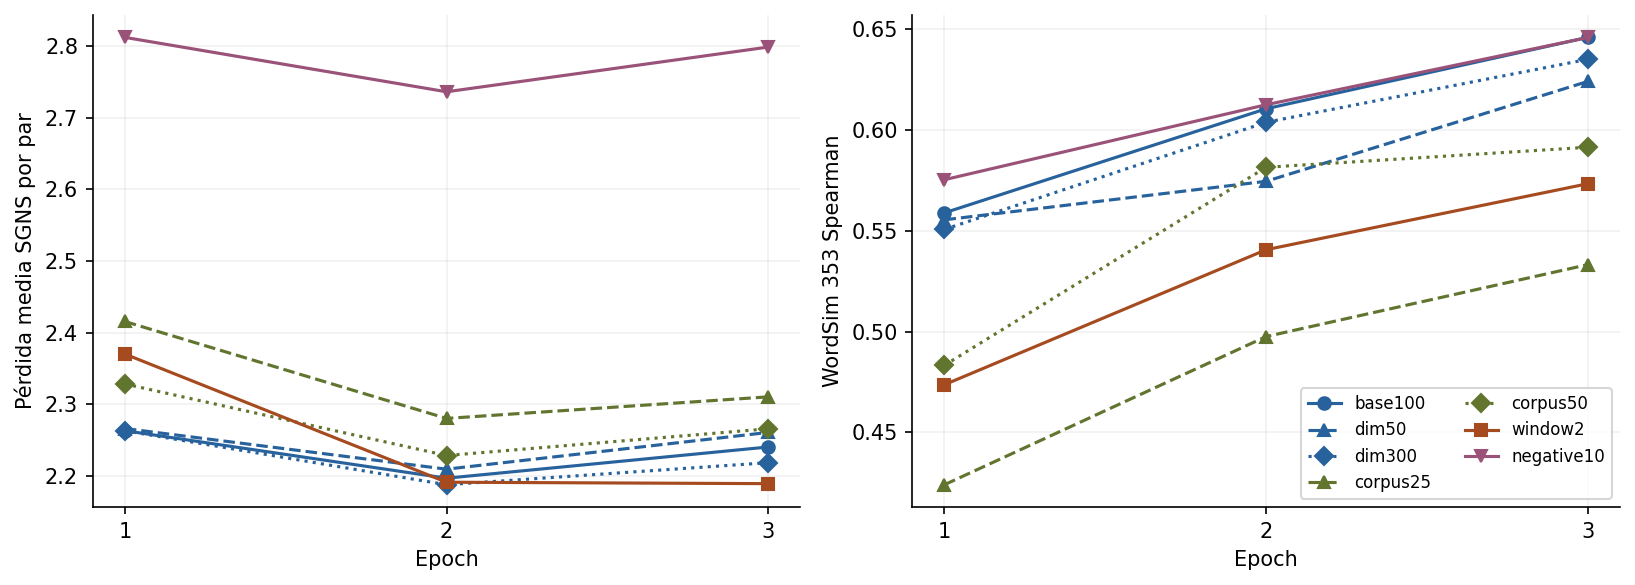

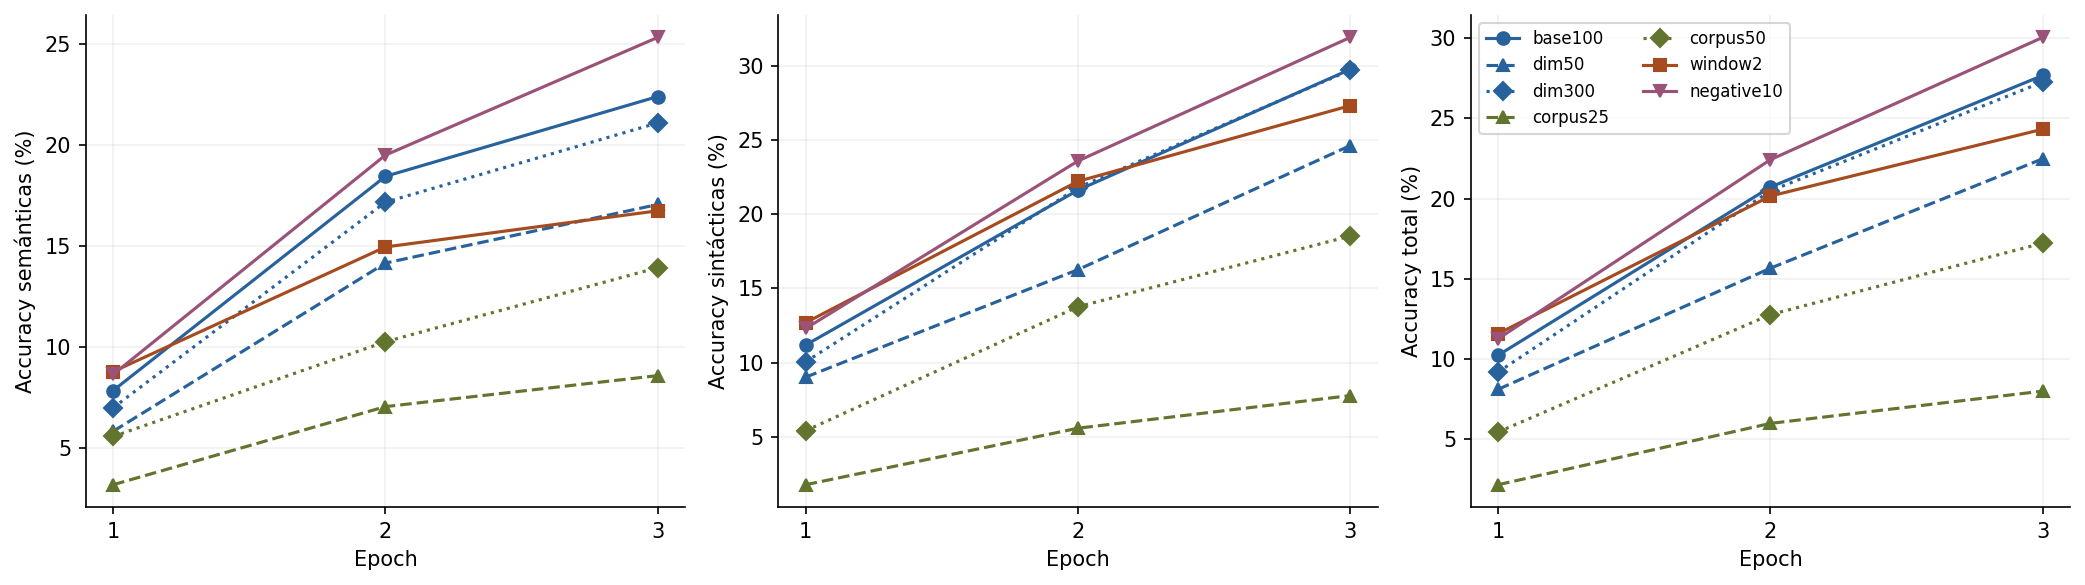

In [8]:
subs=[]
for cfg in configuraciones:
    for row in load_json(ART/'runs'/f"{cfg['name']}.json"):
        for word,stats in row['subsampling'].items():
            subs.append({'configuración':cfg['name'],'epoch':row['epoch'],'palabra':word,**stats})
display(pd.DataFrame(subs))
display(Image(filename=str(ART/'figures'/'sgns_curves.png')))
display(Image(filename=str(ART/'figures'/'sgns_accuracy.png')))

La pérdida SGNS depende del número de negativos: los valores absolutos de k=5 y k=10 no son directamente comparables. La selección usa WordSim y analogías, no la menor pérdida entre objetivos diferentes.

In [9]:
neighbors=[]
for cfg in configuraciones:
    for row in load_json(ART/'runs'/f"{cfg['name']}.json"):
        for word,values in row['neighbors'].items():
            neighbors.append({'configuración':cfg['name'],'epoch':row['epoch'],'palabra':word,'vecinos':', '.join(f'{w} ({s:.3f})' for w,s in values)})
display(pd.DataFrame(neighbors))
mejor=load_json(ART/'best_sgns.json')
print('Checkpoint elegido:',mejor['config']['name'],'epoch',mejor['epoch'],'WordSim',mejor['wordsim'])
display(pd.DataFrame([load_json(ART/'hardware.json')]))

,configuración,epoch,palabra,vecinos
0,base100,1,king,"exchequer (0.770), leopold (0.766), prelates (0.762), bourchier (0.758), aquitaine (0.758)"
1,base100,1,france,"netherlands (0.818), spain (0.792), belgium (0.785), italy (0.769), austria (0.765)"
2,base100,1,computer,"simulation (0.811), computers (0.800), stealth (0.799), computing (0.777), refine (0.777)"
3,base100,1,good,"proud (0.744), excellent (0.740), decent (0.730), confident (0.722), natured (0.716)"
4,base100,1,january,"february (0.880), march (0.844), november (0.843), april (0.837), july (0.831)"
5,base100,1,run,"quainton (0.758), straightened (0.745), pip (0.734), widen (0.732), detoured (0.731)"
6,base100,2,king,"1392 (0.793), aquitaine (0.792), regnal (0.791), lordship (0.782), conqueror (0.777)"
7,base100,2,france,"belgium (0.817), spain (0.814), netherlands (0.796), italy (0.781), germany (0.740)"
8,base100,2,computer,"computers (0.808), simulation (0.773), software (0.748), computing (0.731), desktop (0.729)"
9,base100,2,good,"damn (0.750), admire (0.746), honestly (0.745), always (0.743), decent (0.742)"


Checkpoint elegido: base100 epoch 3 WordSim {'spearman': 0.6460918470920142, 'evaluated': 328, 'total': 353, 'coverage': 0.9291784702549575, 'fixed_selection_pairs': True}


,utc,cpu_model,platform,processor,logical_cpus,python,torch,cuda,gpu,gpu_memory_bytes
0,2026-10-07T05:48:14Z,Intel(R) Xeon(R) CPU @ 2.00GHz,Linux-6.6.122+-x86_64-with-glibc2.35,x86_64,2,3.12.12,2.8.0+cu126,12.6,Tesla T4,15637086208


### Referencia gensim y GloVe
Gensim usa `sg=1`, `hs=0`, la misma dimensión, ventana fija (`shrink_windows=False`), min_count, subsampling, negativos y distribución 0.75; tiene tres epochs y las mismas tasas inicial/final. Se verifica igualdad del vocabulario y del archivo de corpus por SHA256. Su entrenamiento usa Cython y cuatro workers; las actualizaciones asíncronas, orden, implementación del muestreo y aprendizaje secuencial producen diferencias incluso con una semilla igual. Gensim descarta un negativo que coincide con el positivo, mientras esta implementación lo redibuja. Su pérdida acumulada se diferencia por epoch, pero no es directamente comparable con la media SGNS por par.

El gráfico de accuracy contra tokens usa candidatos y preguntas fijos sobre la intersección de las siete variantes SGNS y GloVe. La evaluación final usa la intersección de los tres embeddings finales; por eso su cobertura y accuracy pueden diferir de las de selección.

Se carga **exactamente `glove-wiki-gigaword-100`**, con 400,000 palabras, 100 dimensiones y entrenamiento publicado sobre 6 mil millones de tokens. No se reentrena GloVe en este laboratorio. El artículo original describe dos Intel Xeon E5-2658 de 2.1 GHz: 85 minutos para coocurrencias en un hilo y 14 minutos por iteración para vectores de **300 dimensiones** con 32 cores. Esos tiempos no son mediciones de `glove.6B.100d`, ni deben compararse como si fueran del mismo hardware/corpus/dimensión.

[Gensim Word2Vec](https://radimrehurek.com/gensim/models/word2vec.html) · [GloVe](https://nlp.stanford.edu/projects/glove/)

def train_gensim(best,meta,selection_words,device):
    final=CHECKPOINTS/"gensim.kv"
    if final.exists() and (ART/"runs"/"gensim.json").exists():
        return KeyedVectors.load(str(final)),load_json(ART/"runs"/"gensim.json")
    cfg=best["config"]
    sentences=LineSentence(str(ART/"ids"/cfg["name"]/"corpus.txt"))
    model=Word2Vec(vector_size=cfg["dim"],window=cfg["window"],min_count=cfg["min_count"],
                  sample=cfg["sample"],sg=1,hs=0,negative=cfg["negatives"],ns_exponent=0.75,
                  alpha=cfg["initial_lr"],min_alpha=cfg["final_lr"],workers=4,
                  seed=cfg["seed"],epochs=cfg["epochs"],shrink_windows=False,compute_loss=True)
    model.build_vocab(sentences)
    assert set(model.wv.index_to_key)==set(meta["vocabulary"])
    class Recorder(CallbackAny2Vec):
        def __init__(self):
            self.logs=[]
            self.previous=0
        def on_epoch_begin(self,model):
            self.started=time.perf_counter()
        def on_epoch_

,epoch,config,loss_sum,training_seconds,gpu_peak_bytes,process_rss_bytes,wordsim,accuracy
0,1,"{'dim': 100, 'window': 5, 'negatives': 5, 'fraction': 1.0, 'min_count': 5, 'sample': 0.0001, 'epochs': 3, 'initial_lr': 0.025, 'final_lr': 0.0001, 'batch_si...",37266220.0,114.834639,None,1796558848,0.528868,0.101675
1,2,"{'dim': 100, 'window': 5, 'negatives': 5, 'fraction': 1.0, 'min_count': 5, 'sample': 0.0001, 'epochs': 3, 'initial_lr': 0.025, 'final_lr': 0.0001, 'batch_si...",23164964.0,114.330961,None,1797685248,0.602253,0.208557
2,3,"{'dim': 100, 'window': 5, 'negatives': 5, 'fraction': 1.0, 'min_count': 5, 'sample': 0.0001, 'epochs': 3, 'initial_lr': 0.025, 'final_lr': 0.0001, 'batch_si...",6978928.0,113.932868,None,1798033408,0.641315,0.279545


,model,tokens,vocabulary_size,dimension,download_load_seconds,source,published_runtime_note
0,glove-wiki-gigaword-100,6000000000,400000,100,51.197433,https://nlp.stanford.edu/projects/glove/,"El artículo reporta 85 min para coocurrencias (un hilo) y 14 min por iteración de 300d (32 cores), dual Intel Xeon E5-2658 2.1 GHz. No es un tiempo medido d..."


,epoch,palabra,vecinos
0,1,king,"confessor (0.753), urse (0.751), lordship (0.750), 1292 (0.747), voyk (0.745)"
1,1,france,"italy (0.826), belgium (0.786), algeria (0.757), luxembourg (0.751), germany (0.745)"
2,1,computer,"simulation (0.813), computers (0.790), customized (0.773), interactive (0.764), havok (0.760)"
3,1,good,"terribly (0.793), damn (0.786), unbelievable (0.782), glad (0.781), bothered (0.777)"
4,1,january,"april (0.871), december (0.855), february (0.847), march (0.837), november (0.826)"
5,1,run,"drive (0.789), bama (0.776), bramall (0.767), binghamton (0.764), kettering (0.760)"
6,2,king,"lordship (0.776), offa (0.767), 1199 (0.764), aquitaine (0.762), confessor (0.757)"
7,2,france,"spain (0.827), italy (0.825), belgium (0.798), luxembourg (0.764), austria (0.751)"
8,2,computer,"computers (0.802), simulation (0.793), software (0.767), upload (0.757), gumball (0.754)"
9,2,good,"decent (0.756), unbelievable (0.755), tremendously (0.754), natured (0.749), exciting (0.746)"


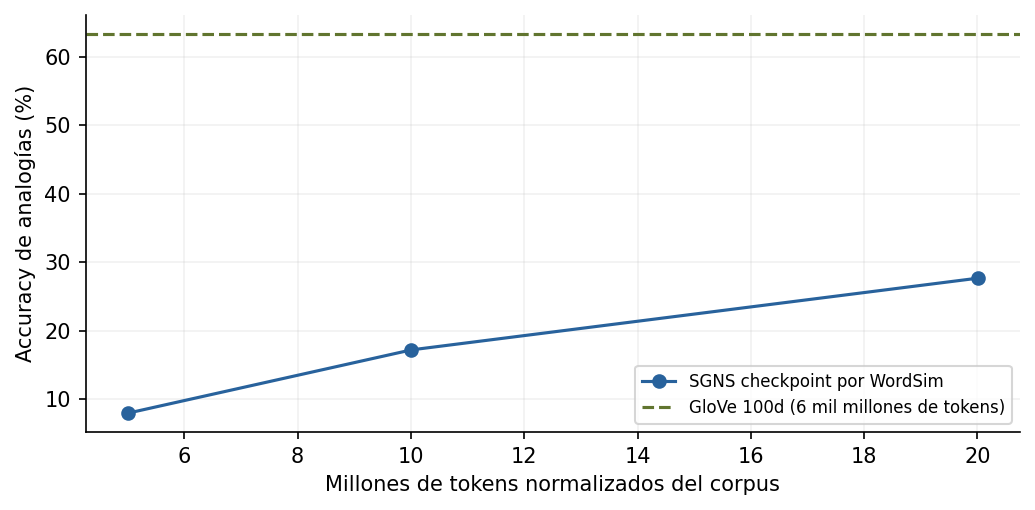

In [10]:
gensim_log=load_json(ART/'runs'/'gensim.json')
print(inspect.getsource(train_gensim))
display(pd.DataFrame([{k:v for k,v in r.items() if k not in ['neighbors','analogies','wordsim']} | {'wordsim':r['wordsim']['spearman'],'accuracy':r['analogies']['total']['accuracy']} for r in gensim_log]))
display(pd.DataFrame([load_json(ART/'glove_source.json')]))
display(pd.DataFrame([{'epoch':r['epoch'],'palabra':w,'vecinos':', '.join(f'{word} ({s:.3f})' for word,s in neighbors)} for r in gensim_log for w,neighbors in r['neighbors'].items()]))
display(Image(filename=str(ART/'figures'/'analogy_vs_tokens.png')))

## 3 Aritmética vectorial y evaluación intrínseca

`analogia(a,b,c,k)` implementa **3CosAdd**: normaliza cada palabra y busca vecinos por coseno de $\hat b-\hat a+\hat c$. Se excluyen a, b y c, como `gensim.most_similar`; se verifica igualdad del top-5 y similitudes con tolerancia numérica. **3CosMul** define $s(x,w)=(1+cos(x,w))/2$ y maximiza $s(x,b)s(x,c)/(s(x,a)+10^{-6})$, usando cosenos desplazados a [0,1].

El benchmark tiene 19,544 preguntas y 14 categorías. Se exige que las cuatro palabras estén en los mismos 30,000 candidatos compartidos para todos los modelos. Accuracy se divide entre preguntas cubiertas, y cobertura entre todas las preguntas; un resultado alto con baja cobertura no significa éxito global. La columna de categorías permite distinguir relaciones semánticas y sintácticas. WordSim y SimLex finales reportan cobertura propia de cada modelo; WordSim utilizado para selección usa pares fijos.

Spearman compara rangos de cosenos y puntuaciones humanas, sin asumir una relación lineal. WordSim-353 incluye asociaciones y relaciones de significado; SimLex-999 se diseñó para medir similitud, diferenciándola de asociación. Por eso las correlaciones pueden cambiar de un benchmark a otro. [SimLex-999](https://fh295.github.io/simlex.html).

In [11]:
print(inspect.getsource(AnalogyEngine.analogia))
display(tablas['comparison'].set_index('model').T)
display(tablas['categories'].round(5))
intrinsic=load_json(ART/'evaluations'/'intrinsic.json')
assert len(load_json(ART/'shared_vocabulary.json'))==30000
assert len({r['three_cos_add']['total']['evaluated'] for r in intrinsic.values()})==1
print('Mismas preguntas cubiertas y 30000 candidatos en los tres embeddings.')

    def analogia(self,a,b,c,k=5,exclude=True):
        """a es a b como c es a ?: normaliza cada vector de la consulta."""
        query = F.normalize(self.query_vector(a,b,c),dim=0)
        scores = self.vectors@query
        if exclude:
            for word in {a,b,c}:
                if word in self.index:
                    scores[self.index[word]]=-torch.inf
        values,indices=torch.topk(scores,min(k,len(self.words)))
        return [(self.words[i],float(s)) for i,s in zip(indices.cpu().tolist(),values.cpu().tolist())]



model,sgns,gensim,glove
dimension,100,100,100
vocabulary,72216,72216,400000
semantic,0.212403,0.222739,0.603618
syntactic,0.314826,0.318296,0.672251
semantic_mul,0.198708,0.20801,0.572868
syntactic_mul,0.290774,0.29568,0.65849
analogy_add,0.282408,0.288051,0.650528
analogy_mul,0.261634,0.267932,0.63139
analogy_coverage,0.625614,0.625614,0.625614
wordsim,0.643579,0.634911,0.532735


,model,method,category,total,evaluated,correct,coverage,accuracy
0,sgns,three_cos_add,capital-common-countries,506,462,152,0.91304,0.32900
1,sgns,three_cos_add,capital-world,4524,1250,238,0.27630,0.19040
2,sgns,three_cos_add,currency,866,70,0,0.08083,0.00000
3,sgns,three_cos_add,city-in-state,2467,1746,269,0.70774,0.15407
4,sgns,three_cos_add,family,506,342,163,0.67589,0.47661
5,sgns,three_cos_add,gram1-adjective-to-adverb,992,812,37,0.81855,0.04557
6,sgns,three_cos_add,gram2-opposite,812,306,20,0.37685,0.06536
7,sgns,three_cos_add,gram3-comparative,1332,1260,443,0.94595,0.35159
8,sgns,three_cos_add,gram4-superlative,1122,702,137,0.62567,0.19516
9,sgns,three_cos_add,gram5-present-participle,1056,870,207,0.82386,0.23793


Mismas preguntas cubiertas y 30000 candidatos en los tres embeddings.

In [12]:
from gensim.models import KeyedVectors
from src.common import sha256
import urllib.request
_motor_analogia=None
def analogia(a,b,c,k=5):
    """3CosAdd sobre el mejor SGNS; carga los vectores solo en la primera llamada."""
    global _motor_analogia
    if _motor_analogia is None:
        archivo=CHECKPOINTS/'best_sgns.kv'
        if not archivo.exists():
            archivo.parent.mkdir(exist_ok=True)
            urllib.request.urlretrieve('https://github.com/iancumes/Lab7DeepLearning/releases/download/v1.0-lab7/best_sgns.kv',archivo)
        manifiesto=ART/'vector_release.json'
        if manifiesto.exists(): assert sha256(archivo)==load_json(manifiesto)['sha256']
        _motor_analogia=AnalogyEngine(KeyedVectors.load(str(archivo)))
    return _motor_analogia.analogia(a,b,c,k)
display(pd.DataFrame(analogia('man','woman','king',5),columns=['palabra','coseno']))

,palabra,coseno
0,aquitaine,0.671460
1,palatine,0.662495
2,dowager,0.656323
3,electress,0.655479
4,tsar,0.654171


In [13]:
personal=load_json(ART/'evaluations'/'personal_analogies.json')
analogias=[]
for model,rows in personal.items():
    for r in rows:
        analogias.append({'modelo':model,'tipo':r['category'],'consulta':f"{r['a']} : {r['b']} :: {r['c']} : ?",'esperado':r['expected'],'rango':r['rank'],'coseno_correcto':r['cosine'],'top5':', '.join(f'{w} ({s:.3f})' for w,s in r['top5']),'sin_exclusión':', '.join(f'{w} ({s:.3f})' for w,s in r['without_exclusion']),'oov':r['oov']})
display(pd.DataFrame(analogias))

,modelo,tipo,consulta,esperado,rango,coseno_correcto,top5,sin_exclusión,oov
0,sgns,gender,man : woman :: king : ?,queen,110,0.599379,"aquitaine (0.671), palatine (0.662), dowager (0.656), electress (0.655), tsar (0.654)","king (0.767), aquitaine (0.671), palatine (0.662), dowager (0.656), electress (0.655)",[]
1,sgns,gender,boy : girl :: father : ?,mother,4,0.705735,"husband (0.740), daughter (0.738), wife (0.729), mother (0.706), betrothed (0.700)","father (0.777), husband (0.740), daughter (0.738), wife (0.729), mother (0.706)",[]
2,sgns,gender,brother : sister :: uncle : ?,aunt,1,0.743972,"aunt (0.744), grandmother (0.696), granddaughter (0.696), louise (0.692), niece (0.678)","sister (0.806), aunt (0.744), uncle (0.715), grandmother (0.696), granddaughter (0.696)",[]
3,sgns,capital,france : paris :: germany : ?,berlin,1,0.751738,"berlin (0.752), munich (0.693), vienna (0.681), moscow (0.654), budapest (0.646)","berlin (0.752), paris (0.734), germany (0.728), munich (0.693), vienna (0.681)",[]
4,sgns,capital,italy : rome :: japan : ?,tokyo,8,0.540954,"kong (0.591), hong (0.579), 989 (0.559), rescript (0.557), restated (0.551)","japan (0.688), kong (0.591), hong (0.579), rome (0.569), 989 (0.559)",[]
5,sgns,capital,spain : madrid :: england : ?,london,623,0.595014,"harrogate (0.790), kennington (0.776), notts (0.775), coventry (0.771), blackpool (0.758)","harrogate (0.790), kennington (0.776), notts (0.775), coventry (0.771), blackpool (0.758)",[]
6,sgns,nationality,france : french :: italy : ?,italian,1,0.851773,"italian (0.852), romanian (0.716), austrian (0.705), german (0.680), italians (0.672)","italian (0.852), french (0.788), romanian (0.716), italy (0.714), austrian (0.705)",[]
7,sgns,nationality,germany : german :: japan : ?,japanese,1,0.859697,"japanese (0.860), korean (0.634), tanaka (0.630), maru (0.629), kondo (0.628)","japanese (0.860), japan (0.751), german (0.644), korean (0.634), tanaka (0.630)",[]
8,sgns,nationality,spain : spanish :: england : ?,english,1,0.694987,"english (0.695), yorkshire (0.651), welsh (0.648), worcestershire (0.639), nottinghamshire (0.632)","england (0.704), english (0.695), yorkshire (0.651), welsh (0.648), worcestershire (0.639)",[]
9,sgns,comparative,good : better :: bad : ?,worse,3,0.625226,"bigger (0.649), harder (0.630), worse (0.625), recap (0.595), unbearable (0.585)","better (0.764), bad (0.685), bigger (0.649), harder (0.630), worse (0.625)",[]


Se evalúan 18 analogías en seis tipos: género, capitales, nacionalidades, comparativos, pasado y plurales. El rango correcto se calcula entre todos los candidatos del modelo, excluyendo las consultas. El top-5 sin exclusión muestra por qué una entrada como `king` puede dominar la búsqueda. La similitud con la respuesta esperada y su rango permiten distinguir una aproximación semántica de un acierto exacto.

El paralelismo se mide mediante $cos(b-a,d-c)$ para relaciones equivalentes. Usa diferencias de vectores originales y no implica necesariamente una analogía correcta: el ruido, la norma y competidores léxicos también influyen. La proyección t-SNE permite explorar vecindades, pero sus ejes, distancias globales y tamaños de grupos no tienen interpretación semántica directa.

,mean_cosine,evaluated,by_category
sgns,0.447161,18,"{'gender': 0.2853066325187683, 'capital': 0.3915784607330958, 'nationality': 0.6875565846761068, 'comparative': 0.5753235419591268, 'past': 0.36451438069343..."
gensim,0.456376,18,"{'gender': 0.2604479243357976, 'capital': 0.4420009255409241, 'nationality': 0.6611936489741007, 'comparative': 0.5990121265252432, 'past': 0.32478312651316..."
glove,0.596173,18,"{'gender': 0.5813054045041403, 'capital': 0.6012488206227621, 'nationality': 0.8225186268488566, 'comparative': 0.5857718388239542, 'past': 0.42395539085070..."


sgns aciertos top1: 11 / 18
Ejemplo de acierto: brother sister uncle → aunt
Ejemplo de fallo: spain madrid england esperado london top1 ['harrogate', 0.7898215055465698] rango 623
gensim aciertos top1: 10 / 18
Ejemplo de acierto: france paris germany → berlin
Ejemplo de fallo: spain madrid england esperado london top1 ['wigan', 0.7606227397918701] rango 760
glove aciertos top1: 16 / 18
Ejemplo de acierto: man woman king → queen
Ejemplo de fallo: spain madrid england esperado london top1 ['manchester', 0.8262481093406677] rango 16


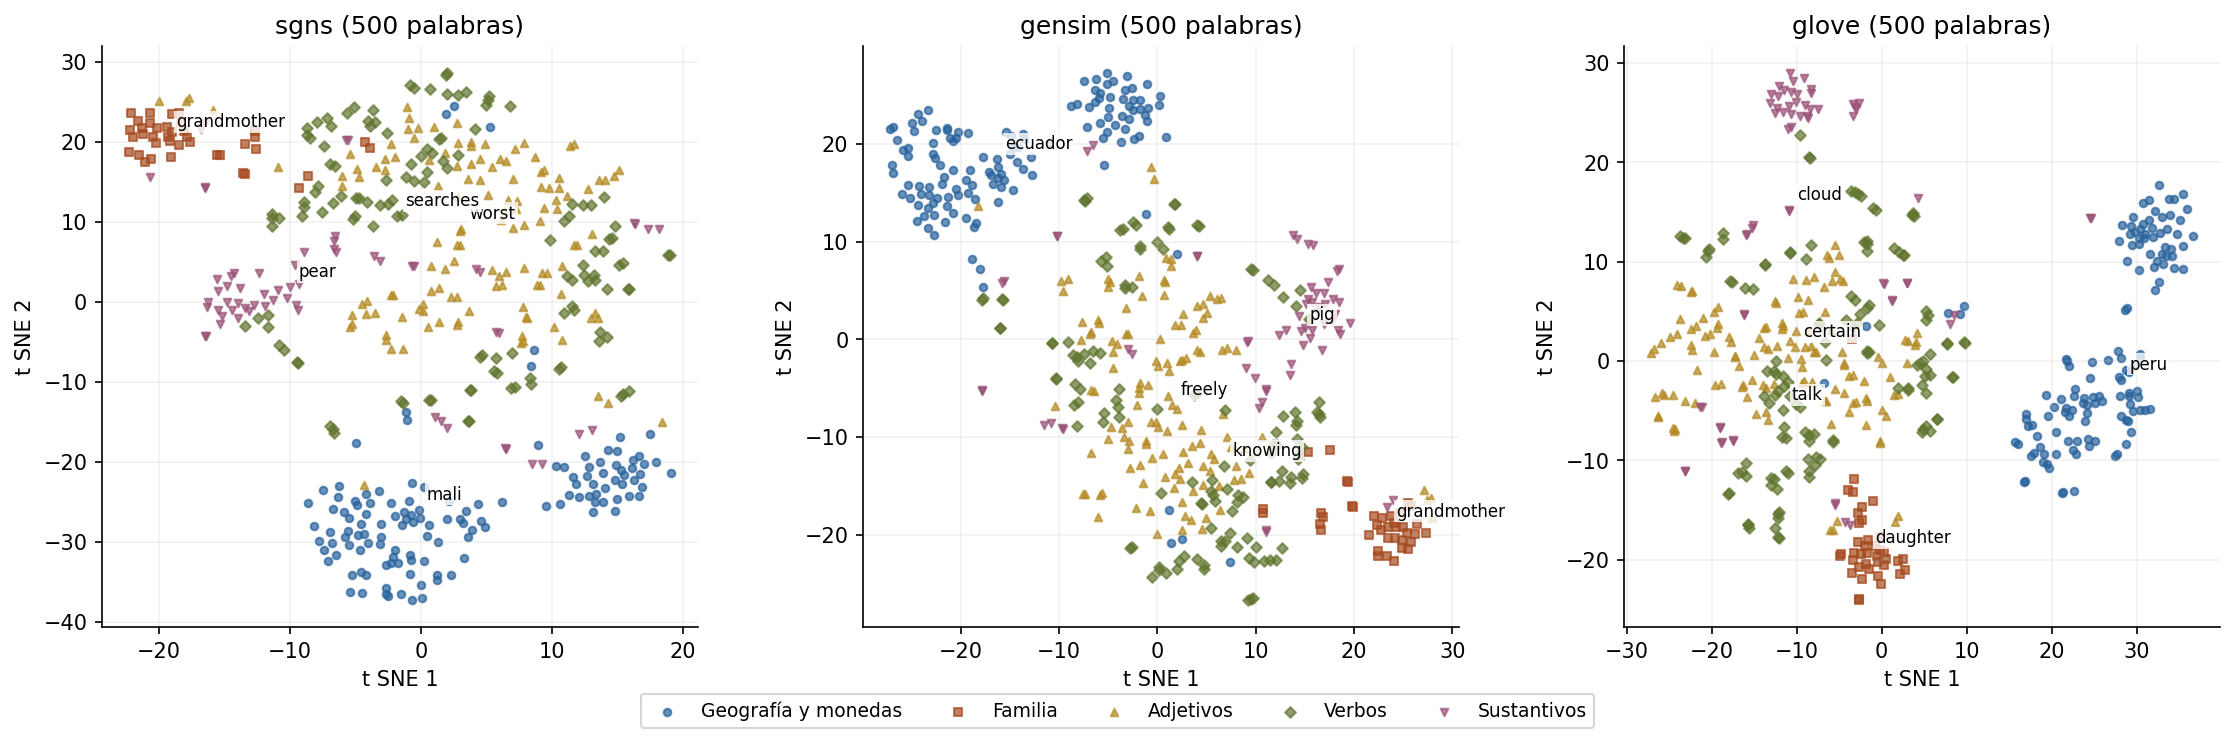

Grupos léxicos definidos por categorías de analogías; ejes y distancias globales no tienen interpretación semántica directa.


In [14]:
display(pd.DataFrame(load_json(ART/'evaluations'/'parallelism.json')).T)
for model,rows in personal.items():
    cubiertos=[r for r in rows if not r['oov']]
    aciertos=[r for r in cubiertos if r['rank']==1]
    fallos=sorted([r for r in cubiertos if r['rank']>1],key=lambda r:r['rank'],reverse=True)
    print(model,'aciertos top1:',len(aciertos),'/',len(cubiertos))
    if aciertos: print('Ejemplo de acierto:',aciertos[0]['a'],aciertos[0]['b'],aciertos[0]['c'],'→',aciertos[0]['expected'])
    if fallos: print('Ejemplo de fallo:',fallos[0]['a'],fallos[0]['b'],fallos[0]['c'],'esperado',fallos[0]['expected'],'top1',fallos[0]['top5'][0],'rango',fallos[0]['rank'])
display(Image(filename=str(ART/'figures'/'tsne.png')))
print(load_json(ART/'tsne_selection.json')['note'])

## 4 Clasificación AG News

Se separa el entrenamiento oficial estratificadamente en 108,000 ejemplos de entrenamiento y 12,000 de validación. El test oficial tiene 7,600 ejemplos. Las fracciones 1/10/50/100 % son prefijos anidados por clase del entrenamiento. Cada vocabulario y TF-IDF se construye únicamente desde su fracción; nunca desde validación/test.

La referencia TF-IDF usa unigramas/bigramas, min_df=2, hasta 100,000 características y regresión logística L2 optimizada con `SGDClassifier(loss='log_loss')`. Los modelos neuronales comparten `EmbeddingBag(mean) → Linear(d,128) → ReLU → Dropout(0.2) → Linear(128,4)`, Adam 1e-3 y batch 512. La entrada se adapta a la dimensión de cada embedding. El vocabulario conserva hasta 50,000 palabras con frecuencia ≥2, más padding y UNK.

Se compara inicialización aleatoria ajustable de 100d con SGNS, gensim y GloVe, cada uno congelado y ajustable. Los OOV de embeddings preentrenados parten de cero; congelados no contribuyen contenido léxico, ajustables pueden aprender. Los modelos neuronales comparten documentos y orden de minibatches; TF-IDF usa las mismas particiones. Máximo 10 epochs y parada después de dos epochs sin mejorar F1 macro. Se selecciona congelado/ajustable y checkpoint con validación. El manifiesto fija decisiones y hashes **antes** de evaluar test. Cada uno de los 20 modelos seleccionados (5 referencias × 4 fracciones) se evalúa una sola vez; sus predicciones y matrices quedan guardadas.

Los tiempos neuronales miden entrenamiento y validación desde la primera epoch; excluyen codificación e inicialización de embeddings. El tiempo de TF-IDF incluye ajuste y transformación de características, además de entrenamiento y validación. Se informa este alcance para evitar interpretar los tiempos como costos idénticos de preparación.

In [15]:
split=load_json(ART/'news_split.json')
train=set(split['train_indices']); val=set(split['validation_indices'])
assert not train & val
subsets=[set(split['subsets'][str(f)]) for f in [.01,.1,.5,1.0]]
assert all(subsets[i]<=subsets[i+1]<=train for i in range(3))
display(pd.DataFrame([{'fracción':f,'ejemplos':len(split['subsets'][str(f)])} for f in [.01,.1,.5,1.0]]))
display(pd.DataFrame([{'modelo':m,'split':s,**r} for m,parts in split['oov'].items() for s,r in parts.items()]))
print(inspect.getsource(NewsClassifier))
print(inspect.getsource(train_neural))
print(inspect.getsource(train_tfidf))

,fracción,ejemplos
0,0.01,1080
1,0.10,10800
2,0.50,54000
3,1.00,108000


,modelo,split,tokens,unknown_tokens,unknown_fraction
0,sgns,train,5051047,170265,0.033709
1,sgns,validation,560816,18655,0.033264
2,sgns,test,352155,11704,0.033235
3,gensim,train,5051047,170265,0.033709
4,gensim,validation,560816,18655,0.033264
5,gensim,test,352155,11704,0.033235
6,glove,train,5051047,46473,0.009201
7,glove,validation,560816,4979,0.008878
8,glove,test,352155,3114,0.008843


class NewsClassifier(nn.Module):
    """EmbeddingBag con offsets evita padding y promedia una bolsa por noticia."""
    def __init__(self,weights,freeze=False):
        super().__init__()
        self.embedding=nn.EmbeddingBag.from_pretrained(weights,freeze=freeze,mode="mean",padding_idx=0)
        self.mlp=nn.Sequential(nn.Linear(weights.shape[1],128),nn.ReLU(),nn.Dropout(0.2),nn.Linear(128,4))
    def forward(self,flat_ids,offsets):
        return self.mlp(self.embedding(flat_ids,offsets))

def train_neural(name,initialization,freeze,fraction,news,kv,device):
    folder=ART/"classifiers"
    folder.mkdir(parents=True,exist_ok=True)
    key=f'{name}_{int(fraction*100):03d}'
    result_path=ART/"runs"/(key+".json")
    if result_path.exists() and (folder/(key+".pt")).exists():
        return load_json(result_path)
    subset=news["subsets"][str(fraction)]
    train_tokens=[news["tokens"][i] for i in subset]
    val_tokens=[news["tokens"][i] for i in news["validation"]]
    y=news["labe

,modelo,fracción,epoch,parámetros,entrenables,segundos,accuracy,precision_macro,recall_macro,f1_macro
0,tfidf,0.01,10,31372,31372,3.60144,0.82667,0.82573,0.82667,0.82589
1,random,0.01,3,426644,426644,1.01696,0.46333,0.23907,0.46333,0.31253
2,sgns_frozen,0.01,4,426644,13444,0.20555,0.70417,0.75816,0.70417,0.70045
3,sgns_finetune,0.01,4,426644,426644,0.23186,0.72292,0.77242,0.72292,0.71963
4,gensim_frozen,0.01,8,426644,13444,0.35922,0.78708,0.80618,0.78708,0.78713
5,gensim_finetune,0.01,8,426644,426644,0.39318,0.80958,0.81757,0.80958,0.80857
6,glove_frozen,0.01,3,426644,13444,0.17403,0.66442,0.68420,0.66442,0.66278
7,glove_finetune,0.01,3,426644,426644,0.17667,0.66775,0.69193,0.66775,0.66653
8,tfidf,0.10,10,262512,262512,10.45891,0.90208,0.90168,0.90208,0.90171
9,random,0.10,10,1633444,1633444,1.14712,0.89475,0.89461,0.89475,0.89462


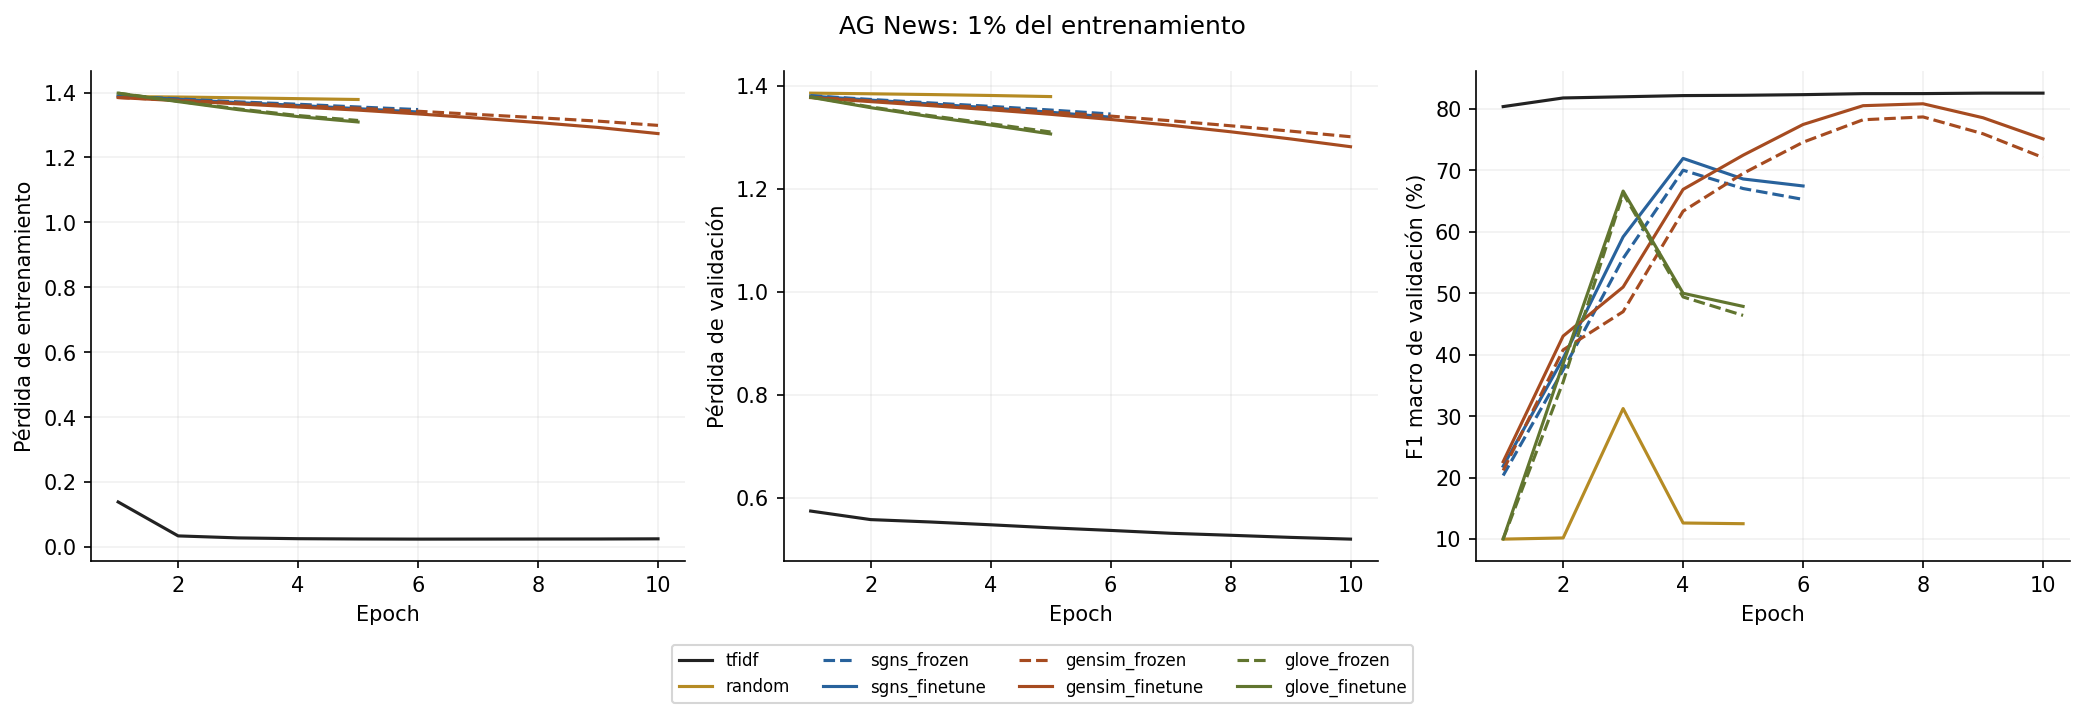

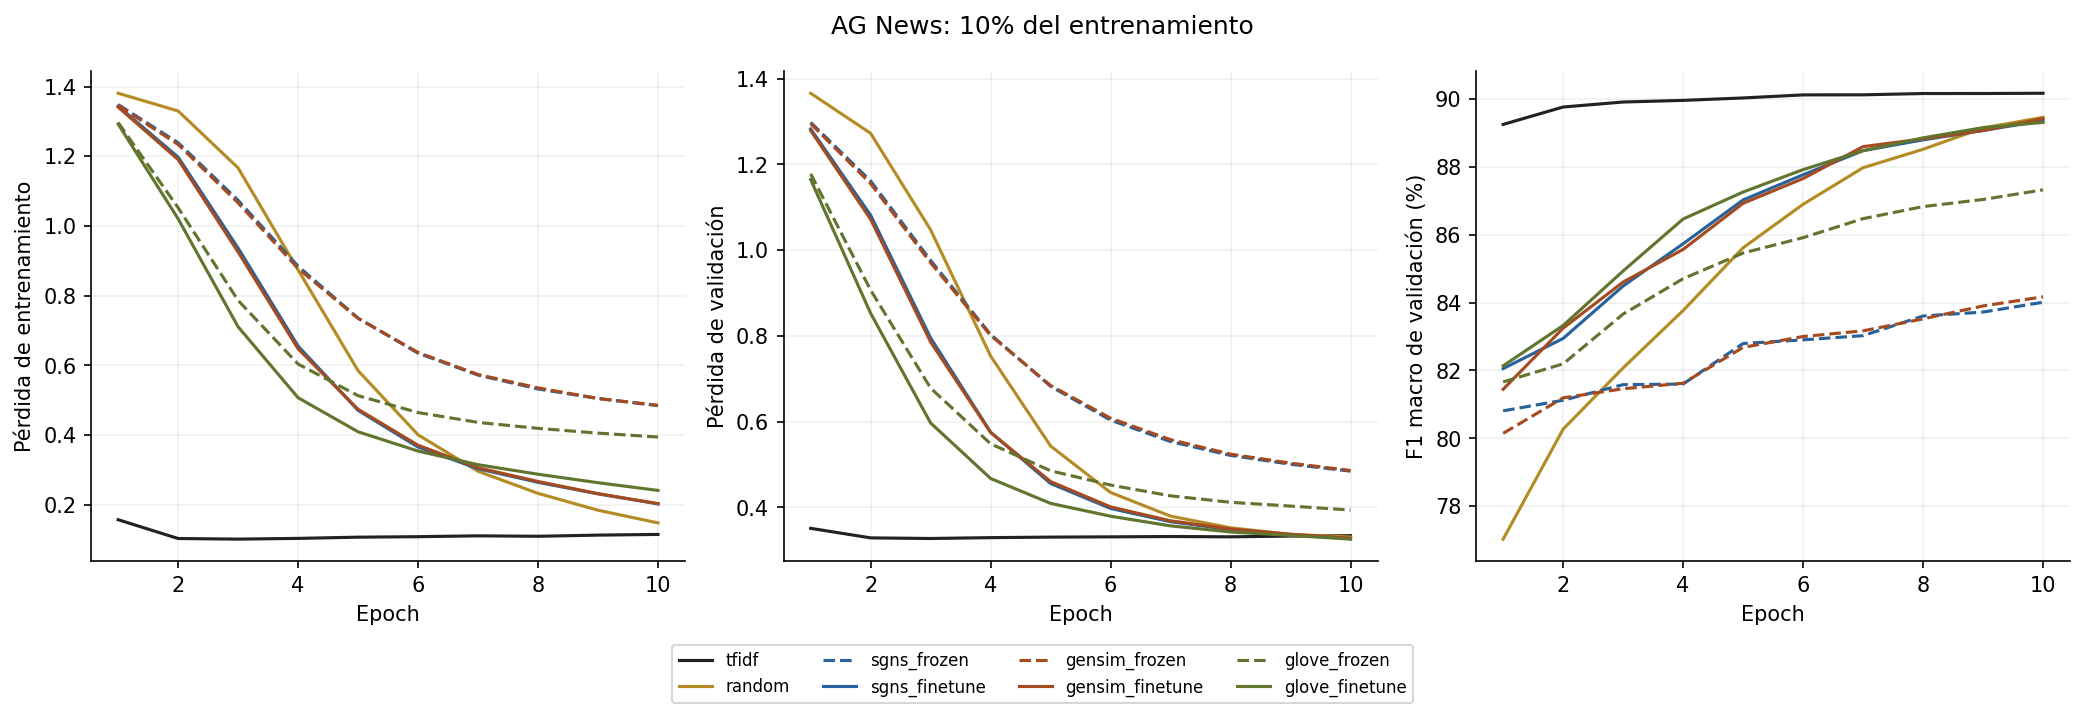

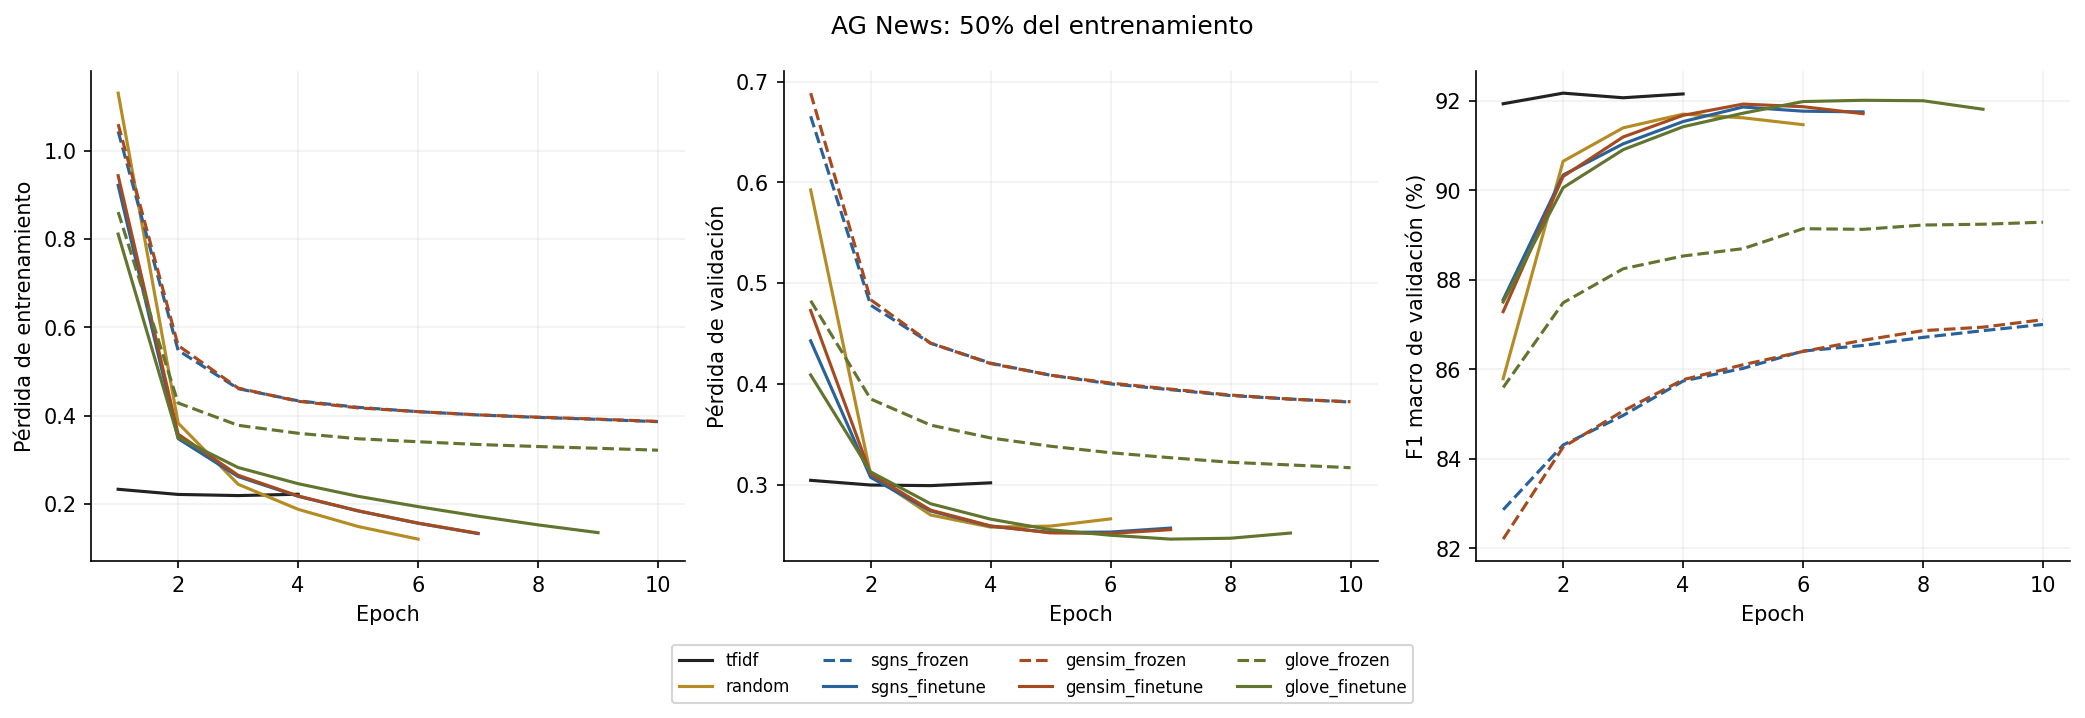

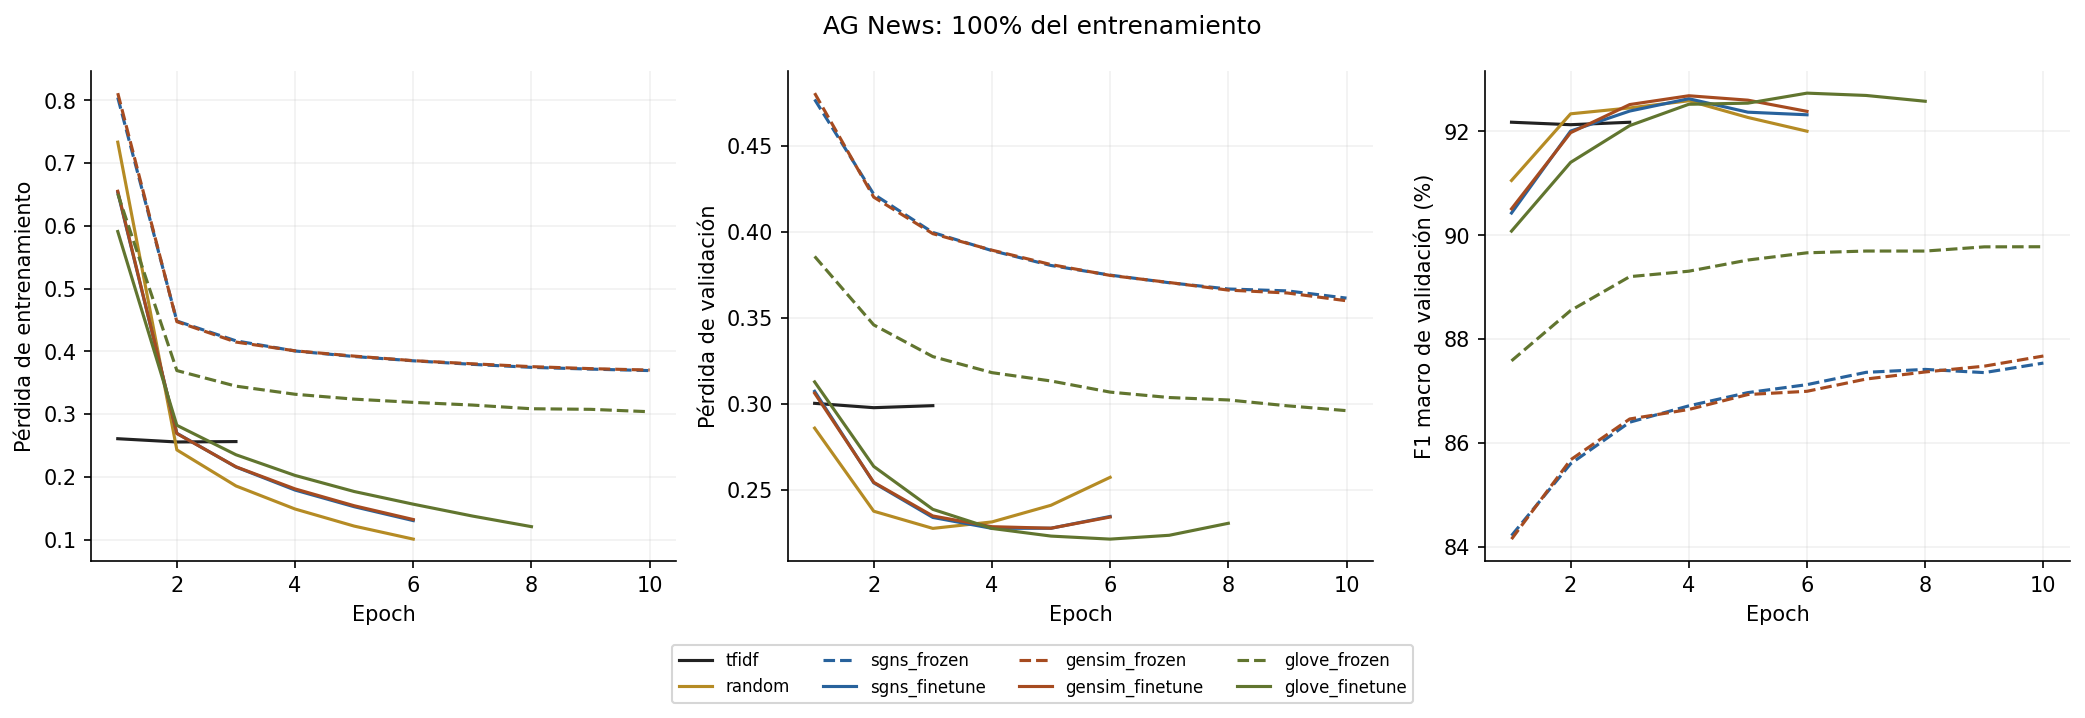

,model,variant,fraction,train_examples,val_f1,best_epoch,seconds,parameters,trainable_parameters,accuracy,precision_macro,recall_macro,f1_macro
0,tfidf,tfidf,0.01,1080,0.82589,10,3.60144,31372,31372,0.82013,0.81916,0.82013,0.81939
1,random,random,0.01,1080,0.31253,3,1.01696,426644,426644,0.46303,0.23836,0.46303,0.31203
2,sgns,sgns_finetune,0.01,1080,0.71963,4,0.23186,426644,426644,0.72289,0.77101,0.72289,0.71890
3,gensim,gensim_finetune,0.01,1080,0.80857,8,0.39318,426644,426644,0.80724,0.81375,0.80724,0.80679
4,glove,glove_finetune,0.01,1080,0.66653,3,0.17667,426644,426644,0.66842,0.69255,0.66842,0.66734
5,tfidf,tfidf,0.10,10800,0.90171,10,10.45891,262512,262512,0.89316,0.89268,0.89316,0.89277
6,random,random,0.10,10800,0.89462,10,1.14712,1633444,1633444,0.88763,0.88746,0.88763,0.88748
7,sgns,sgns_finetune,0.10,10800,0.89365,10,1.28966,1633444,1633444,0.89211,0.89189,0.89211,0.89191
8,gensim,gensim_finetune,0.10,10800,0.89424,10,1.09613,1633444,1633444,0.89053,0.89042,0.89053,0.89031
9,glove,glove_finetune,0.10,10800,0.89311,10,1.08527,1633444,1633444,0.89250,0.89233,0.89250,0.89228


In [16]:
seleccion=load_json(ART/'classification_selection.json')
display(pd.DataFrame([{'modelo':r['name'],'fracción':r['fraction'],'epoch':r['best_epoch'],'parámetros':r['total_parameters'],'entrenables':r['trainable_parameters'],'segundos':r['training_seconds'],**r['validation']} for r in seleccion['all_results']]).round(5))
for fraction in [1,10,50,100]:
    display(Image(filename=str(ART/'figures'/f'classification_curves_{fraction}.png')))
display(tablas['classifiers'].round(5))
assert all(r['test_evaluations']==1 for r in load_json(ART/'evaluations'/'classification_test.json'))

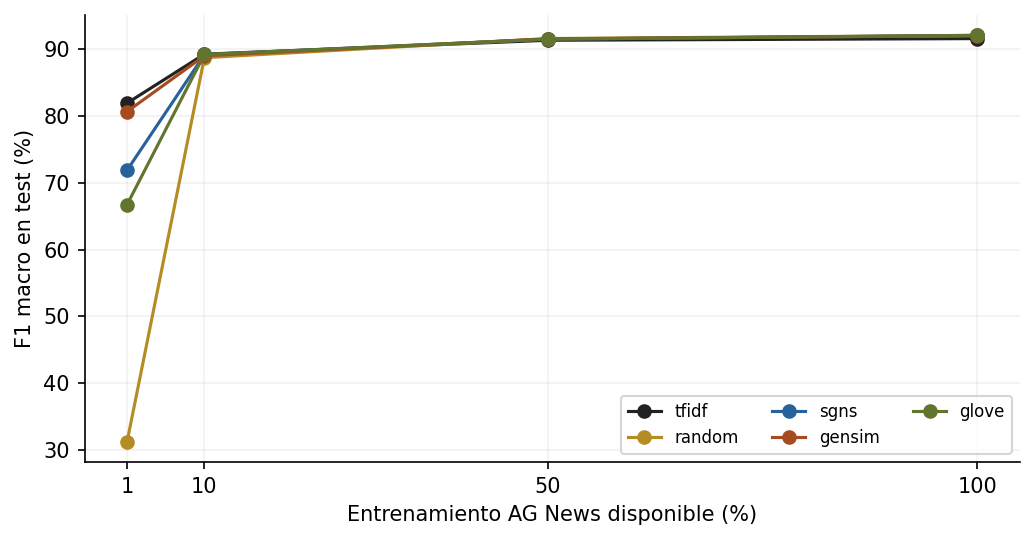

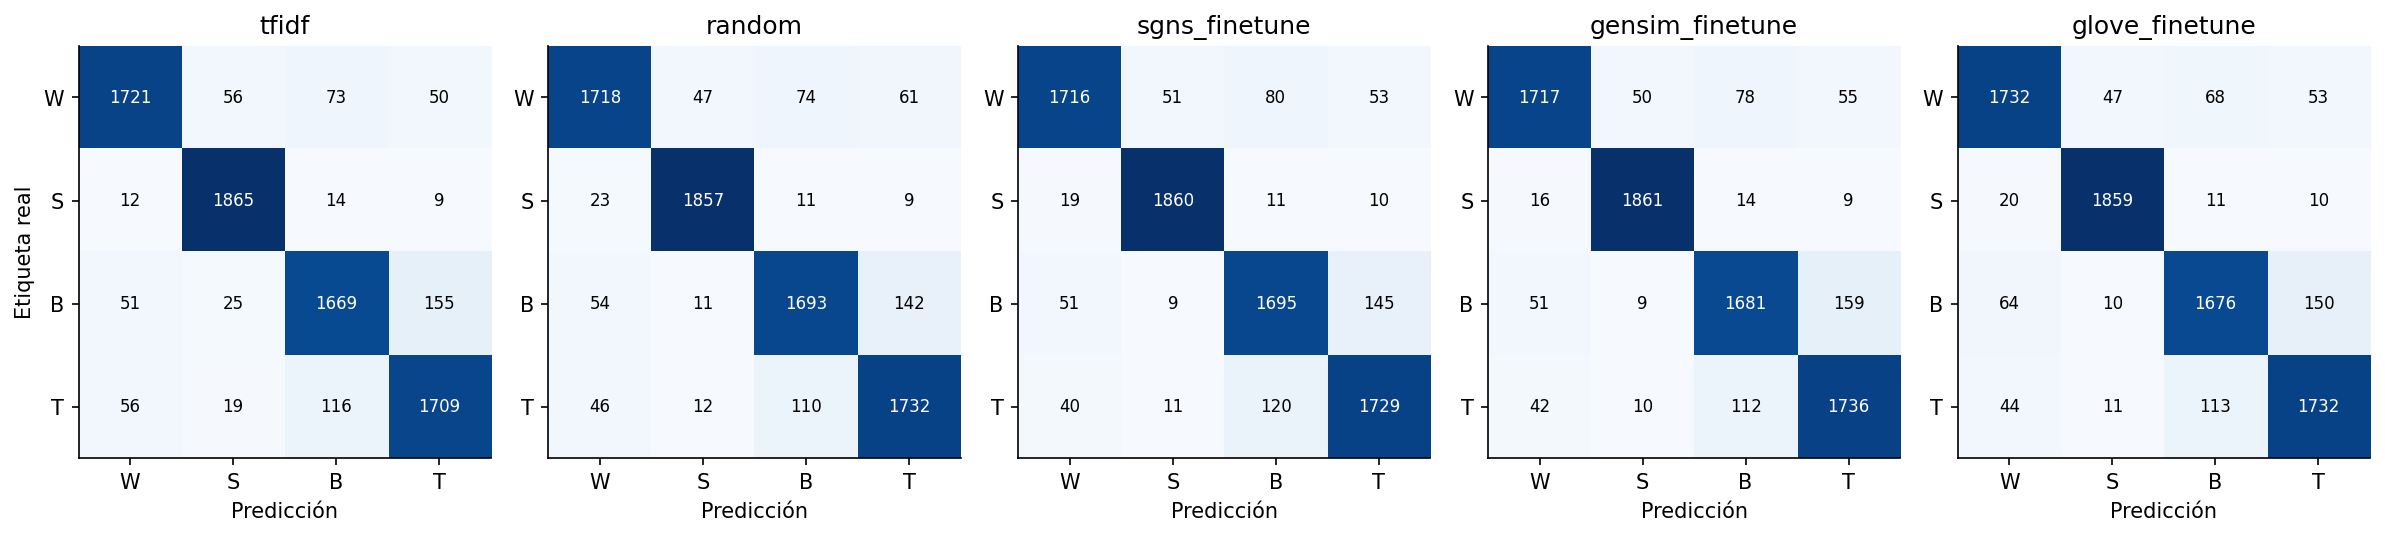

model,gensim,glove,random,sgns,tfidf
fraction,,,,,
0.01,0.80679,0.66734,0.31203,0.71890,0.81939
0.10,0.89031,0.89228,0.88748,0.89191,0.89277
0.50,0.91580,0.91523,0.91616,0.91527,0.91363
1.00,0.92035,0.92083,0.92099,0.92101,0.91610


Ganancia GloVe sobre aleatorio por fracción:


fraction
0.01    0.355316
0.10    0.004802
0.50   -0.000934
1.00   -0.000166
Name: Δ F1 macro, dtype: float64

In [17]:
display(Image(filename=str(ART/'figures'/'classification_vs_data.png')))
display(Image(filename=str(ART/'figures'/'confusion_matrices.png')))
comparacion=tablas['classifiers'].pivot(index='fraction',columns='model',values='f1_macro')
display(comparacion.round(5))
print('Ganancia GloVe sobre aleatorio por fracción:')
display((comparacion.glove-comparacion.random).rename('Δ F1 macro'))

## 5 Conclusiones y límites

Las conclusiones siguientes se calculan desde las tablas guardadas. Se distingue selección por validación de evaluación final. Tres epochs y una sola semilla limitan la evidencia: no se atribuyen diferencias pequeñas a una superioridad general ni se inventan intervalos de confianza. Las operaciones dispersas CUDA y los workers asíncronos de gensim pueden introducir variación numérica al repetir; los pesos publicados se identifican por hash. GloVe usa un corpus mucho mayor; su ventaja puede reflejar datos, optimización y arquitectura. Los modelos Bag ignoran orden y negación; TF-IDF con bigramas recupera parte de ese orden local. Fine-tuning puede corregir dominio/OOV, pero con pocas etiquetas también puede sobreajustar.

In [18]:
comp=tablas['comparison']
clas=tablas['classifiers']
print('SGNS seleccionado:',mejor['config']['name'],'epoch',mejor['epoch'])
print('Mayor accuracy intrínseca 3CosAdd:',comp.loc[comp.analogy_add.idxmax(),'model'])
print('Mayor Spearman SimLex:',comp.loc[comp.simlex.idxmax(),'model'])
for fraction in [.01,.1,.5,1.0]:
    rows=clas[clas.fraction==fraction]
    winner=rows.loc[rows.f1_macro.idxmax()]
    print(f"Con {fraction*100:g}% de entrenamiento, mejor F1 test observado: {winner['variant']} = {winner.f1_macro:.4f}")
print('Archivo de datos y decisiones:',ART/'classification_selection.json')
print('Entorno real:',load_json(ART/'hardware.json'))

SGNS seleccionado: base100 epoch 3
Mayor accuracy intrínseca 3CosAdd: glove
Mayor Spearman SimLex: glove
Con 1% de entrenamiento, mejor F1 test observado: tfidf = 0.8194
Con 10% de entrenamiento, mejor F1 test observado: tfidf = 0.8928
Con 50% de entrenamiento, mejor F1 test observado: random = 0.9162
Con 100% de entrenamiento, mejor F1 test observado: sgns_finetune = 0.9210
Archivo de datos y decisiones: C:\Users\ianro\OneDrive\Documentos\Uvg\Octavo Semestre\Deep Learning\Lab7DeepLearning\artifacts\classification_selection.json
Entorno real: {'utc': '2026-10-07T05:48:14Z', 'cpu_model': 'Intel(R) Xeon(R) CPU @ 2.00GHz', 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.35', 'processor': 'x86_64', 'logical_cpus': 2, 'python': '3.12.12', 'torch': '2.8.0+cu126', 'cuda': '12.6', 'gpu': 'Tesla T4', 'gpu_memory_bytes': 15637086208}


In [19]:
from src.analysis import discussion
display(Markdown(discussion()))

### Interpretación de los resultados observados

La curva log-log de frecuencias muestra la concentración de Zipf: pocas palabras muy frecuentes y una cola larga. No se estimó un exponente universal ni se probó un ajuste estadístico; el patrón visual y las coberturas respaldan su uso descriptivo.

La selección sin redondear eligió base100 epoch 3 (ρ=0.64609185) frente a negative10 epoch 3 (ρ=0.64603420); diferencia 0.00005764. Accuracy solo desempata correlaciones iguales. Una diferencia pequeña con una semilla no demuestra superioridad robusta.

**sgns:** 3CosAdd total 28.24%; semánticas 21.24%, sintácticas 31.48%. La categoría más fuerte fue gram6-nationality-adjective (62.36%) y la más débil currency (0.00%). Se usan las mismas preguntas cubiertas y candidatos.

**gensim:** 3CosAdd total 28.81%; semánticas 22.27%, sintácticas 31.83%. La categoría más fuerte fue gram6-nationality-adjective (61.35%) y la más débil currency (0.00%). Se usan las mismas preguntas cubiertas y candidatos.

**glove:** 3CosAdd total 65.05%; semánticas 60.36%, sintácticas 67.23%. La categoría más fuerte fue gram6-nationality-adjective (97.31%) y la más débil currency (5.71%). Se usan las mismas preguntas cubiertas y candidatos.

En man:woman::king, queen tiene rango 110 y coseno 0.599. Al permitir consultas, el primer resultado es king. El ≈ describe una dirección aproximada, no una identidad exacta ni garantía de recuperar queen. El paralelismo complementa el ranking, pero tampoco garantiza el acierto.

A epoch 3, **dim50**: WordSim 0.624 frente a 0.646 de base100; analogías 22.48% frente a 27.67%. Semánticas 17.06%, sintácticas 24.61%. Tiempo total 7.6 minutos.

A epoch 3, **dim300**: WordSim 0.635 frente a 0.646 de base100; analogías 27.27% frente a 27.67%. Semánticas 21.09%, sintácticas 29.69%. Tiempo total 7.5 minutos.

A epoch 3, **corpus25**: WordSim 0.533 frente a 0.646 de base100; analogías 8.00% frente a 27.67%. Semánticas 8.58%, sintácticas 7.78%. Tiempo total 1.6 minutos.

A epoch 3, **corpus50**: WordSim 0.592 frente a 0.646 de base100; analogías 17.23% frente a 27.67%. Semánticas 13.93%, sintácticas 18.52%. Tiempo total 3.2 minutos.

A epoch 3, **window2**: WordSim 0.573 frente a 0.646 de base100; analogías 24.32% frente a 27.67%. Semánticas 16.74%, sintácticas 27.30%. Tiempo total 2.7 minutos.

A epoch 3, **negative10**: WordSim 0.646 frente a 0.646 de base100; analogías 30.05% frente a 27.67%. Semánticas 25.33%, sintácticas 31.90%. Tiempo total 9.9 minutos.

Reducir ventana 5→2 cambió accuracy sintáctica -2.44 puntos y semántica -5.66 puntos. Esto describe esta ejecución; no demuestra que ventanas pequeñas siempre favorezcan sintaxis. Con corpus 25/50/100% cambia además el vocabulario min_count y la frecuencia, aun usando preguntas comunes: se prueba la escala del pipeline completo.

En evaluación final compartida, GloVe frente a SGNS: +36.81 puntos de accuracy; gensim frente a SGNS: +0.56. El experimento de corpus ofrece evidencia de escala dentro de SGNS, pero no permite repartir causalmente la diferencia con GloVe entre corpus y método. GloVe usa 6 mil millones de tokens y otra optimización. Gensim actualiza secuencialmente con cuatro workers, mientras SGNS suma gradientes de 4096 pares; cambia también el tratamiento de colisiones de negativos y el orden de muestreo.

Una pérdida menor no asegura mejores embeddings: SGNS separa pares reales y ruido; WordSim y analogías miden relaciones específicas. Aumentar k cambia el número de términos de la pérdida; no es válido ordenar k=5 y k=10 por su valor bruto.

Ejemplo observado dentro del mismo objetivo: base100, epochs 2→3, pérdida 2.1965→2.2401, mientras WordSim mejora 0.6107→0.6461. Por tanto, menor pérdida tampoco ordena necesariamente la calidad entre epochs de una misma configuración.

Con 1% de etiquetas, F1 macro test: tfidf 81.94%, random 31.20%, sgns 71.89%, gensim 80.68%, glove 66.73%. Validación eligió sgns_finetune, gensim_finetune, glove_finetune. GloVe frente a aleatorio: +35.53 puntos. Se describen estas diferencias después de cerrar decisiones, sin volver a elegir variantes.

Con 10% de etiquetas, F1 macro test: tfidf 89.28%, random 88.75%, sgns 89.19%, gensim 89.03%, glove 89.23%. Validación eligió sgns_finetune, gensim_finetune, glove_finetune. GloVe frente a aleatorio: +0.48 puntos. Se describen estas diferencias después de cerrar decisiones, sin volver a elegir variantes.

Con 50% de etiquetas, F1 macro test: tfidf 91.36%, random 91.62%, sgns 91.53%, gensim 91.58%, glove 91.52%. Validación eligió sgns_finetune, gensim_finetune, glove_finetune. GloVe frente a aleatorio: -0.09 puntos. Se describen estas diferencias después de cerrar decisiones, sin volver a elegir variantes.

Con 100% de etiquetas, F1 macro test: tfidf 91.61%, random 92.10%, sgns 92.10%, gensim 92.03%, glove 92.08%. Validación eligió sgns_finetune, gensim_finetune, glove_finetune. GloVe frente a aleatorio: -0.02 puntos. Se describen estas diferencias después de cerrar decisiones, sin volver a elegir variantes.

Al 100%, los dos mayores F1 test observados fueron sgns_finetune (0.92101117) y random (0.92099100); diferencia 0.0020 puntos porcentuales. El orden observado no demuestra una ventaja robusta y no se usó para volver a seleccionar variantes.

t-SNE representa vecindades y permite inspeccionar agrupaciones léxicas con solapamientos; los temas se asignaron antes de proyectar. Algunas categorías son gramaticales y mezclan significados. No se interpretan ejes ni separaciones globales como una escala de calidad. Tres epochs, una semilla y las actualizaciones asíncronas de gensim limitan la generalización; no hay intervalos de confianza ni afirmaciones de significancia.

### Entregables y reproducción

- Código y dependencias: `src/`, `scripts/`, `requirements.txt`.
- Registros por epoch: `artifacts/runs/`; tablas CSV, figuras y métricas JSON.
- Predicciones finales y matrices: `artifacts/evaluations/`.
- Informe de máximo cinco páginas y versión Word editable: `entregables/`.
- [Vectores del mejor SGNS](https://github.com/iancumes/Lab7DeepLearning/releases/download/v1.0-lab7/best_sgns.kv).

Los checkpoints por epoch se preservan en el respaldo de entrenamiento; los archivos grandes no se incorporan al historial Git. Para regenerar t-SNE se cargan los tres `.kv` y se ejecuta `src.reporting.tsne`. Las coordenadas y selección de palabras ya están publicadas. Los datos se descargan desde sus fuentes originales; los hashes identifican el corpus empleado.

### Referencias
1. Mikolov et al. (2013), *Distributed Representations of Words and Phrases and their Compositionality*, NeurIPS.
2. Pennington, Socher y Manning (2014), *GloVe: Global Vectors for Word Representation*, EMNLP. https://nlp.stanford.edu/pubs/glove.pdf
3. PyTorch 2.8, documentación de Embedding y EmbeddingBag.
4. Gensim 4.4, documentación de Word2Vec y KeyedVectors.
5. [WikiText-103](https://huggingface.co/datasets/Salesforce/wikitext), [AG News](https://huggingface.co/datasets/fancyzhx/ag_news).
6. Hill, Reichart y Korhonen (2015), *SimLex-999: Evaluating Semantic Models with Similarity Estimation*, Computational Linguistics. [Recurso original](https://fh295.github.io/simlex.html).

Repositorio de la entrega: https://github.com/iancumes/Lab7DeepLearning